# 🏆 The Golden Rules of Training & Optimizing a Neural Network
## Dataset: Hand Landmarks (Gesture Recognition)

---

| Step | Goal | Strategy |
|------|------|----------|
| 1️⃣ | **Sanity Check** — Code Verification | 1 sample + tiny model |
| 2️⃣ | **Establish a Baseline** — Good Enough | Full data + simple model |
| 3️⃣ | **Reduce Bias** — Fix Underfitting | Full data + complex model |
| 4️⃣ | **Reduce Variance** — Fix Overfitting | Full data + complex model + Regularisation → 🥇 Gold Standard |

> 💡 Think of it like building a house: check your tools (Step 1) → basic structure (Step 2) → make it bigger (Step 3) → reinforce it to last (Step 4).

## 📦 Section 0 — Reproducibility Setup
Fixing seeds = same results every run. No surprises! 🔒

Only the built-in standard library (`os`, `random`, `sys`, `platform`) is imported here — no third-party libraries yet.

In [16]:
# ============================================================
#  SECTION 0 — REPRODUCIBILITY SEEDS
#  Only standard-library imports here (no version needed).
#  Every third-party library is imported in the cell that
#  first uses it, with its version printed right there.
# ============================================================

import os
import sys
import random
import platform

# Print Python & system info — useful baseline for reproducibility
print('=' * 55)
print('  🖥️  SYSTEM INFO')
print('=' * 55)
print(f'  Python   : {sys.version.split()[0]}')
print(f'  Platform : {platform.system()} {platform.release()}')
print('=' * 55)

# ------------------------------------------------------------------
# Reproducibility master function
# We define it here so every later cell can call set_all_seeds(SEED)
# before doing anything random.
# ------------------------------------------------------------------
def set_all_seeds(seed: int = 42):
    """
    Locks every source of randomness in one shot.
    Call this at the top of every experiment block!
    """
    random.seed(seed)                           # Python built-in RNG
    os.environ['PYTHONHASHSEED'] = str(seed)    # Python hash randomisation
    # NumPy + PyTorch seeds are set in their own cells
    # after those libraries are imported.

SEED = 42
set_all_seeds(SEED)

print(f'\n  ✅ SEED set to : {SEED}')
print(f'  ✅ Python RNG  : locked')
print(f'  ✅ PYTHONHASHSEED = {os.environ["PYTHONHASHSEED"]}')
print('\n  👉 Ready — third-party libs will be imported in their own cells.')

  🖥️  SYSTEM INFO
  Python   : 3.13.2
  Platform : Windows 10

  ✅ SEED set to : 42
  ✅ Python RNG  : locked
  ✅ PYTHONHASHSEED = 42

  👉 Ready — third-party libs will be imported in their own cells.


## 📂 Section 1 — Load the Hand Landmarks Dataset

Libraries used here: **NumPy**, **Pandas**

21 hand landmarks × (x, y, z) = **63 features per sample**. Last column = gesture label.

In [17]:
# ============================================================
#  SECTION 1 — LOAD DATASET
#  Libraries introduced: numpy, pandas
# ============================================================

import numpy as np          # numerical arrays & math
import pandas as pd         # CSV loading & dataframes

# Extend the seed lock now that NumPy is available
np.random.seed(SEED)

# Print versions right where the libraries are imported
print('  📦 LIBRARIES IMPORTED IN THIS CELL')
print(f'  NumPy  version : {np.__version__}')
print(f'  Pandas version : {pd.__version__}')
print()

# ── Load CSV ──────────────────────────────────────────────────
#  👇 THE ONLY LINE YOU NEED TO CHANGE — set your CSV path:
#
#  Option A) Colab upload  → 'hand_landmarks_data.csv'
#  Option B) Google Drive  → '/content/drive/MyDrive/hand_landmarks_data.csv'
#             (mount first:  from google.colab import drive; drive.mount('/content/drive'))
#  Option C) Local Jupyter → r'C:/Users/you/Downloads/hand_landmarks_data.csv'

DATA_PATH = 'hand_landmarks_data.csv'   # ✏️  ← CHANGE THIS

df = pd.read_csv(DATA_PATH)

# Auto-detect label column (always the last column)
LABEL_COL = df.columns[-1]

# ── Print everything worth knowing about the loaded data ──────
print('=' * 55)
print('  📂 DATASET LOADED')
print('=' * 55)
print(f'  File             : {DATA_PATH}')
print(f'  Rows (samples)   : {df.shape[0]}')
print(f'  Columns (total)  : {df.shape[1]}')
print(f'  Feature columns  : {df.shape[1] - 1}')
print(f'  Label column     : "{LABEL_COL}"')
print(f'  Missing values   : {df.isnull().sum().sum()}  ← must be 0!')
print(f'  Duplicate rows   : {df.duplicated().sum()}')
print(f'  Feature dtype    : {df.drop(columns=[LABEL_COL]).dtypes.unique()}')
print(f'  Feature min      : {df.drop(columns=[LABEL_COL]).min().min():.4f}')
print(f'  Feature max      : {df.drop(columns=[LABEL_COL]).max().max():.4f}')
print(f'  Feature mean     : {df.drop(columns=[LABEL_COL]).mean().mean():.4f}')
print(f'  Feature std      : {df.drop(columns=[LABEL_COL]).std().mean():.4f}')
print()
print(f'  📊 Class Distribution:')
print(df[LABEL_COL].value_counts().to_string())
print('=' * 55)

df.head()

  📦 LIBRARIES IMPORTED IN THIS CELL
  NumPy  version : 2.2.3
  Pandas version : 2.2.3

  📂 DATASET LOADED
  File             : hand_landmarks_data.csv
  Rows (samples)   : 25675
  Columns (total)  : 64
  Feature columns  : 63
  Label column     : "label"
  Missing values   : 0  ← must be 0!
  Duplicate rows   : 0
  Feature dtype    : [dtype('float64')]
  Feature min      : -36.0509
  Feature max      : 831.4911
  Feature mean     : 142.3214
  Feature std      : 54.1764

  📊 Class Distribution:
label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


## 📊 Section 1b — EDA (Exploratory Data Analysis)

Libraries used here: **Matplotlib**, **Seaborn**

Always **look** at data before training — *Garbage In, Garbage Out!* 🗑️

  📦 LIBRARIES IMPORTED IN THIS CELL
  Matplotlib version : 3.10.8
  Seaborn    version : 0.13.2

  🎨 Plot style set  : seaborn-v0_8-darkgrid



C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\490509786.py:37: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\490509786.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


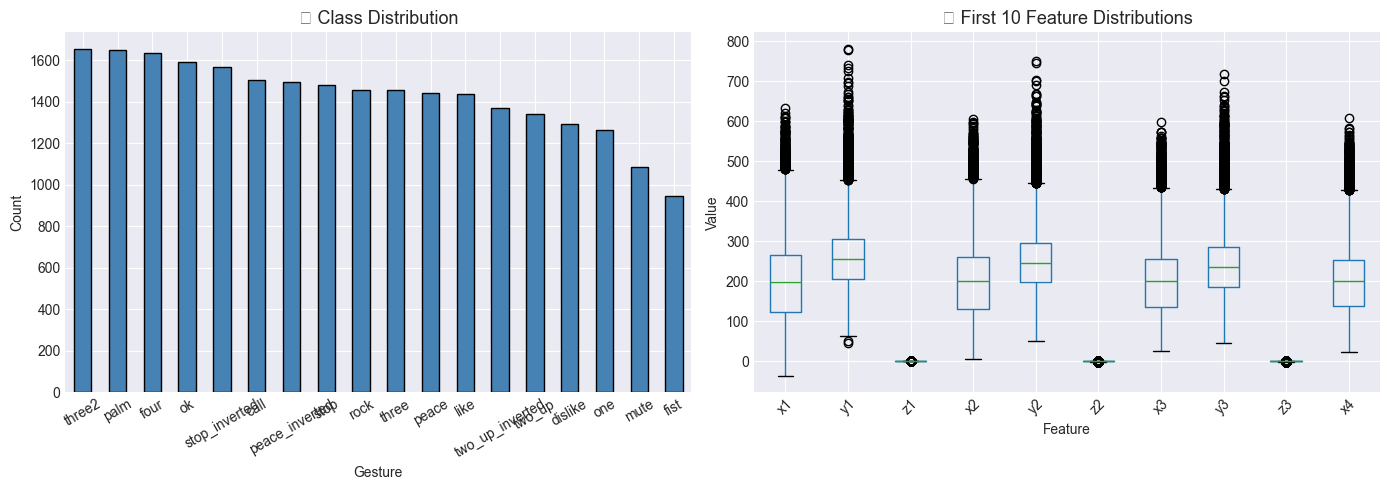

  📋 EDA SUMMARY
  Num classes        : 18
  Most common class  : "three2"  (1653 samples)
  Rarest class       : "fist"  (945 samples)
  Imbalance ratio    : 1.75x  ← consider class weighting ⚠️
  Feature range      : [-36.0509  →  831.4911]  ← will be normalised next


In [18]:
# ============================================================
#  SECTION 1b — EDA
#  Libraries introduced: matplotlib, seaborn
# ============================================================

import matplotlib                        # plotting engine
import matplotlib.pyplot as plt          # pyplot interface
import seaborn as sns                    # statistical plots

# Print versions right where the libraries are imported
print('  📦 LIBRARIES IMPORTED IN THIS CELL')
print(f'  Matplotlib version : {matplotlib.__version__}')
print(f'  Seaborn    version : {sns.__version__}')
print()

plt.style.use('seaborn-v0_8-darkgrid')  # nice clean plot style
print(f'  🎨 Plot style set  : seaborn-v0_8-darkgrid')
print()

# ── Plot 1: class balance ────────────────────────────────────
# Imbalanced classes → biased model! We need to know this early.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df[LABEL_COL].value_counts()
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('🎯 Class Distribution', fontsize=13)
axes[0].set_xlabel('Gesture'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# ── Plot 2: feature spread ───────────────────────────────────
# Very different scales → slow or biased training without normalisation!
df.iloc[:, :10].boxplot(ax=axes[1])
axes[1].set_title('📦 First 10 Feature Distributions', fontsize=13)
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── Print EDA summary numbers ─────────────────────────────────
imbalance_ratio = class_counts.max() / class_counts.min()
print('  📋 EDA SUMMARY')
print(f'  Num classes        : {df[LABEL_COL].nunique()}')
print(f'  Most common class  : "{class_counts.idxmax()}"  ({class_counts.max()} samples)')
print(f'  Rarest class       : "{class_counts.idxmin()}"  ({class_counts.min()} samples)')
print(f'  Imbalance ratio    : {imbalance_ratio:.2f}x  '
      f'{"← balanced ✅" if imbalance_ratio < 1.5 else "← consider class weighting ⚠️"}')
print(f'  Feature range      : [{df.drop(columns=[LABEL_COL]).min().min():.4f}  →  '
      f'{df.drop(columns=[LABEL_COL]).max().max():.4f}]  ← will be normalised next')

## 🔧 Section 2 — Preprocessing

Libraries used here: **Scikit-learn** (`LabelEncoder`, `StandardScaler`), **PyTorch** (`torch`, `nn`, `optim`, `DataLoader`, `TensorDataset`)

Raw CSV → clean PyTorch tensors. Sharpening the pencil before the exam! ✏️

**Golden rule:** fit scaler on **train only** — never let val/test data influence scaling!

In [19]:
# ============================================================
#  SECTION 2 — PREPROCESSING
#  Libraries introduced: scikit-learn, torch
#  Steps: Encode labels → Split → Scale → Tensorize → Loaders
# ============================================================

import sklearn                                          # ML utilities
from sklearn.preprocessing import LabelEncoder, StandardScaler

import torch                                            # deep learning framework
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Print versions right where the libraries are imported
print('  📦 LIBRARIES IMPORTED IN THIS CELL')
print(f'  Scikit-learn version : {sklearn.__version__}')
print(f'  PyTorch      version : {torch.__version__}')
print(f'  CUDA available       : {torch.cuda.is_available()}')
print()

# Now that PyTorch is imported, finish the seed lock
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'  🔒 PyTorch seeds locked')
print(f'  🔒 CUDA deterministic    : {torch.backends.cudnn.deterministic}')
print(f'  🔒 CUDA benchmark off    : {not torch.backends.cudnn.benchmark}')
print(f'  🖥️  Device               : {DEVICE}')
print()

# ── A: Separate features and labels ──────────────────────────
X     = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_raw = df[LABEL_COL].values

# ── B: Encode string labels → integers ───────────────────────
#  e.g. 'fist'→0, 'ok'→1, 'open_palm'→2 ...
label_encoder = LabelEncoder()
y             = label_encoder.fit_transform(y_raw).astype(np.int64)
CLASS_NAMES   = label_encoder.classes_
NUM_CLASSES   = len(CLASS_NAMES)
NUM_FEATURES  = X.shape[1]

# ── C: 70 / 15 / 15 split ────────────────────────────────────
total      = len(X)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

np.random.seed(SEED)                       # re-seed before shuffle!
indices   = np.random.permutation(total)
train_idx = indices[:train_size]
val_idx   = indices[train_size : train_size + val_size]
test_idx  = indices[train_size + val_size :]

X_train_raw, y_train = X[train_idx], y[train_idx]
X_val_raw,   y_val   = X[val_idx],   y[val_idx]
X_test_raw,  y_test  = X[test_idx],  y[test_idx]

# ── D: StandardScaler — fit ONLY on train, transform all ─────
#  Fitting on val/test = data leakage = cheating!
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform
X_val   = scaler.transform(X_val_raw)         # transform only
X_test  = scaler.transform(X_test_raw)        # transform only

# ── E: PyTorch TensorDatasets & DataLoaders ──────────────────
def make_dataset(X_np, y_np):
    return TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.long)
    )

BATCH_SIZE   = 64
train_ds     = make_dataset(X_train, y_train)
val_ds       = make_dataset(X_val,   y_val)
test_ds      = make_dataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Print ALL preprocessing check values ─────────────────────
print('=' * 55)
print('  🔧 PREPROCESSING COMPLETE')
print('=' * 55)
print(f'  Label column       : "{LABEL_COL}"')
print(f'  Classes            : {list(CLASS_NAMES)}')
print(f'  Label encoding     : {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}')
print(f'  Num classes        : {NUM_CLASSES}')
print(f'  Num features       : {NUM_FEATURES}')
print(f'  Total samples      : {total}')
print(f'  Train size         : {len(X_train)}  ({len(X_train)/total*100:.1f}%)')
print(f'  Val   size         : {len(X_val)}   ({len(X_val)/total*100:.1f}%)')
print(f'  Test  size         : {len(X_test)}   ({len(X_test)/total*100:.1f}%)')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Train batches      : {len(train_loader)}')
print(f'  Val   batches      : {len(val_loader)}')
print(f'  Test  batches      : {len(test_loader)}')
print(f'  X_train shape      : {X_train.shape}')
print(f'  X_train mean       : {X_train.mean():.6f}  ← should be ~0.0')
print(f'  X_train std        : {X_train.std():.6f}   ← should be ~1.0')
print(f'  X_val   mean       : {X_val.mean():.6f}')
print(f'  X_test  mean       : {X_test.mean():.6f}')
print('=' * 55)

  📦 LIBRARIES IMPORTED IN THIS CELL
  Scikit-learn version : 1.8.0
  PyTorch      version : 2.10.0+cpu
  CUDA available       : False

  🔒 PyTorch seeds locked
  🔒 CUDA deterministic    : True
  🔒 CUDA benchmark off    : True
  🖥️  Device               : cpu

  🔧 PREPROCESSING COMPLETE
  Label column       : "label"
  Classes            : ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']
  Label encoding     : {'call': 0, 'dislike': 1, 'fist': 2, 'four': 3, 'like': 4, 'mute': 5, 'ok': 6, 'one': 7, 'palm': 8, 'peace': 9, 'peace_inverted': 10, 'rock': 11, 'stop': 12, 'stop_inverted': 13, 'three': 14, 'three2': 15, 'two_up': 16, 'two_up_inverted': 17}
  Num classes        : 18
  Num features       : 63
  Total samples      : 25675
  Train size         : 17972  (70.0%)
  Val   size         : 3851   (15.0%)
  Test  size         : 3852   (15.0%)
  Batch size     

## 🛠️ Section 3 — Training Engine (Helper Functions)

No new libraries here — all already imported above.

Write once, reuse in all 4 steps. DRY = Don't Repeat Yourself! 🔁

In [20]:
# ============================================================
#  SECTION 3 — HELPER FUNCTIONS
#  No new library imports — all already available from Section 2.
#  These 4 functions are the engine behind all Golden Rule steps.
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion):
    """One full pass over training data. Returns (avg_loss, accuracy)."""
    model.train()   # enables Dropout + BatchNorm train-mode
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()              # clear old gradients
        out  = model(X_b)                  # forward pass
        loss = criterion(out, y_b)         # compute loss
        loss.backward()                    # backpropagation
        optimizer.step()                   # weight update
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


@torch.no_grad()   # skip grad tracking → faster + less memory
def evaluate(model, loader, criterion):
    """Evaluate on any DataLoader. Returns (avg_loss, accuracy)."""
    model.eval()    # disables Dropout, switches BatchNorm to eval stats
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        out  = model(X_b)
        loss = criterion(out, y_b)
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


def train_model(model, tr_loader, va_loader, optimizer, criterion, epochs=50):
    """Full N-epoch training loop. Prints every 10 epochs. Returns history dict."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, tr_loader, optimizer, criterion)
        vl, va = evaluate(model, va_loader, criterion)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}/{epochs}'
                  f'  |  Train  loss={tl:.4f}  acc={ta:.3f}'
                  f'  |  Val    loss={vl:.4f}  acc={va:.3f}')
    return history


def plot_history(history, title='Training History'):
    """Side-by-side loss and accuracy curves."""
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(ep, history['train_loss'], label='Train', color='royalblue')
    axes[0].plot(ep, history['val_loss'],   label='Val',   color='tomato', ls='--')
    axes[0].set_title(f'{title}\nLoss Curve')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(ep, history['train_acc'], label='Train', color='royalblue')
    axes[1].plot(ep, history['val_acc'],   label='Val',   color='tomato', ls='--')
    axes[1].set_title(f'{title}\nAccuracy Curve')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f'  Plot summary → Train acc: {history["train_acc"][-1]:.3f}'
          f'  |  Val acc: {history["val_acc"][-1]:.3f}')


# Shared loss function used in all 4 steps
criterion = nn.CrossEntropyLoss()

print('  ✅ Helper functions registered:')
print('     train_one_epoch — forward + backward pass over training data')
print('     evaluate        — no-grad pass over any loader')
print('     train_model     — full N-epoch loop with history dict')
print('     plot_history    — loss & accuracy curves')
print(f'     criterion       — {criterion}')

  ✅ Helper functions registered:
     train_one_epoch — forward + backward pass over training data
     evaluate        — no-grad pass over any loader
     train_model     — full N-epoch loop with history dict
     plot_history    — loss & accuracy curves
     criterion       — CrossEntropyLoss()


---
# 🟢 GOLDEN RULE — STEP 1: Sanity Check (Code Verification)
### Strategy: **1 single sample + tiny model**

No new libraries here — all already imported.

Train on **exactly 1 sample** until loss → 0, accuracy → 100%.
If the model **cannot** memorise 1 sample → the pipeline is broken. 🐛

> 🩺 Like a doctor checking for a heartbeat before running any tests.

  🟢 STEP 1: SANITY CHECK — 1 Single Sample
  Input shape        : [1, 63]
  True label (int)   : 11
  True label (name)  : "rock"
  Model params       : 2,642
  Architecture       : Linear(63→32) ReLU → Linear(32→18)
  Optimizer          : Adam   lr=0.01
  Epochs             : 200

  Epoch  50  |  loss=0.000000  |  acc=1.000
  Epoch 100  |  loss=0.000000  |  acc=1.000
  Epoch 150  |  loss=0.000000  |  acc=1.000
  Epoch 200  |  loss=0.000000  |  acc=1.000

  📊 SANITY CHECK RESULTS
  Epochs trained     : 200
  Final loss         : 0.000000  ← target: near 0.0
  Final accuracy     : 1.000    ← target: 1.000
  Prediction         : "rock"  (true: "rock")
  Correct?           : ✅ YES

  ✅ SANITY CHECK PASSED — pipeline is correct, model CAN learn!


C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\13832505.py:68: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


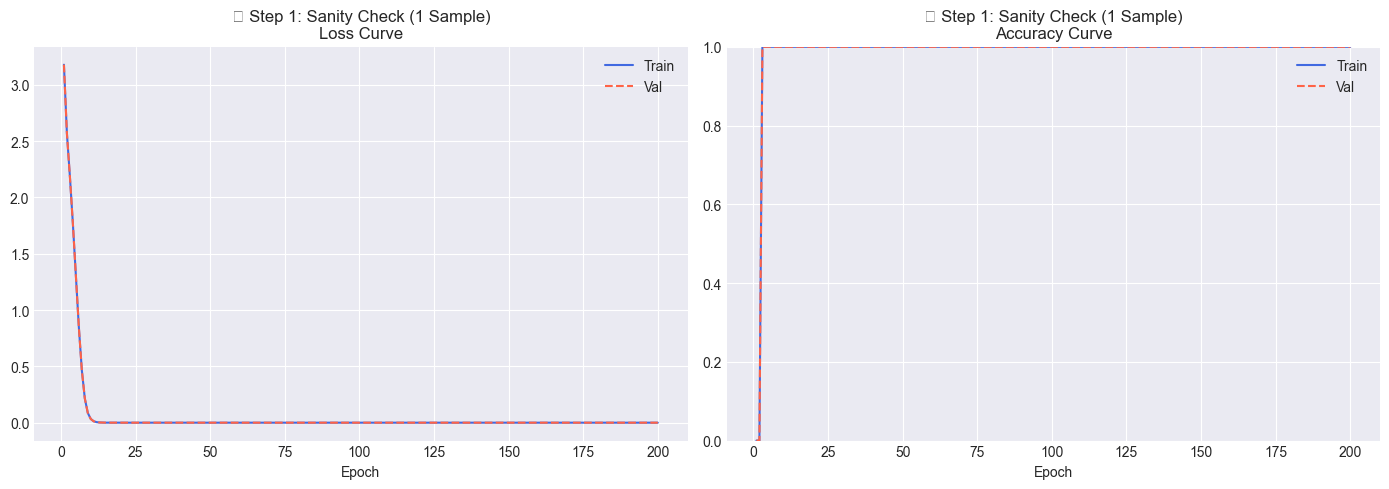

  Plot summary → Train acc: 1.000  |  Val acc: 1.000


In [21]:
# ============================================================
#  🟢 STEP 1 — SANITY CHECK: overfit exactly 1 sample
#  No new library imports — torch, nn, optim already loaded.
#  Expected output: loss → 0.000,  accuracy → 1.000
# ============================================================

torch.manual_seed(SEED)    # re-seed before building model
np.random.seed(SEED)

print('=' * 55)
print('  🟢 STEP 1: SANITY CHECK — 1 Single Sample')
print('=' * 55)

# Tiny 2-layer model — minimal, just enough to verify the pipeline
class TinyModel(nn.Module):
    def __init__(self, in_f, n_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 32), nn.ReLU(),
            nn.Linear(32, n_cls)
        )
    def forward(self, x): return self.net(x)

# Take exactly 1 sample from the training set
X1 = torch.tensor(X_train[:1], dtype=torch.float32).to(DEVICE)   # shape [1, NUM_FEATURES]
y1 = torch.tensor(y_train[:1], dtype=torch.long).to(DEVICE)       # shape [1]
single_loader = DataLoader(TensorDataset(X1, y1), batch_size=1)

sanity_model  = TinyModel(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
sanity_optim  = optim.Adam(sanity_model.parameters(), lr=0.01)
sanity_params = sum(p.numel() for p in sanity_model.parameters() if p.requires_grad)

# Print everything about the setup before training
print(f'  Input shape        : {list(X1.shape)}')
print(f'  True label (int)   : {y1.item()}')
print(f'  True label (name)  : "{CLASS_NAMES[y1.item()]}"')
print(f'  Model params       : {sanity_params:,}')
print(f'  Architecture       : Linear({NUM_FEATURES}→32) ReLU → Linear(32→{NUM_CLASSES})')
print(f'  Optimizer          : Adam   lr=0.01')
print(f'  Epochs             : 200')
print()

# Train 200 epochs on the single sample
sanity_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 201):
    loss, acc = train_one_epoch(sanity_model, single_loader, sanity_optim, criterion)
    sanity_history['train_loss'].append(loss)
    sanity_history['val_loss'].append(loss)
    sanity_history['train_acc'].append(acc)
    sanity_history['val_acc'].append(acc)
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d}  |  loss={loss:.6f}  |  acc={acc:.3f}')

final_loss    = sanity_history['train_loss'][-1]
final_acc     = sanity_history['train_acc'][-1]
final_pred    = CLASS_NAMES[sanity_model(X1).argmax(1).item()]
true_label    = CLASS_NAMES[y1.item()]

print()
print('  📊 SANITY CHECK RESULTS')
print(f'  Epochs trained     : 200')
print(f'  Final loss         : {final_loss:.6f}  ← target: near 0.0')
print(f'  Final accuracy     : {final_acc:.3f}    ← target: 1.000')
print(f'  Prediction         : "{final_pred}"  (true: "{true_label}")')
print(f'  Correct?           : {"✅ YES" if final_pred == true_label else "❌ NO"}')
print()
if final_acc >= 0.99:
    print('  ✅ SANITY CHECK PASSED — pipeline is correct, model CAN learn!')
else:
    print('  ❌ SANITY CHECK FAILED — debug the pipeline before continuing!')
print('=' * 55)

plot_history(sanity_history, title='🟢 Step 1: Sanity Check (1 Sample)')

---
# 🟡 GOLDEN RULE — STEP 2: Establish a Baseline
### Strategy: **Full training data + Simple model**

No new libraries here — all already imported.

No tricks — just a basic model on the full dataset to get a **reference score**.

> 📏 Like measuring your height before a fitness programme!

  🟡 STEP 2: ESTABLISH A BASELINE
  Architecture       : Linear(63→64) ReLU → Linear(64→32) ReLU → Linear(32→18)
  Trainable params   : 6,770
  Optimizer          : Adam   lr=1e-3   weight_decay=0
  Batch size         : 64
  Epochs             : 60
  Random chance acc  : 0.056 (5.6%)  ← must beat this!

  Epoch  10/60  |  Train  loss=0.2570  acc=0.897  |  Val    loss=0.2937  acc=0.887
  Epoch  20/60  |  Train  loss=0.1850  acc=0.933  |  Val    loss=0.2278  acc=0.921
  Epoch  30/60  |  Train  loss=0.1351  acc=0.954  |  Val    loss=0.1742  acc=0.943
  Epoch  40/60  |  Train  loss=0.1067  acc=0.965  |  Val    loss=0.1477  acc=0.958
  Epoch  50/60  |  Train  loss=0.0815  acc=0.976  |  Val    loss=0.1279  acc=0.968
  Epoch  60/60  |  Train  loss=0.0637  acc=0.981  |  Val    loss=0.1253  acc=0.970

  📊 BASELINE RESULTS
  Train loss (final) : 0.0637
  Train acc  (final) : 0.981
  Val   loss (final) : 0.1253
  Val   acc  (final) : 0.970  ← score to BEAT in Step 3
  Test  loss         : 0.1087
 

C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\13832505.py:68: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


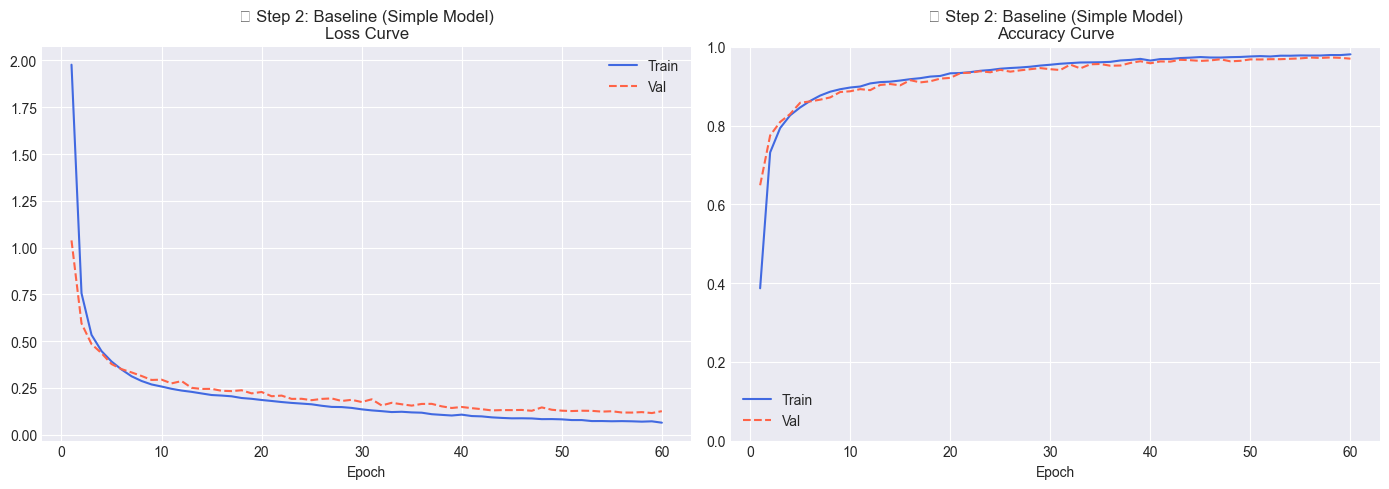

  Plot summary → Train acc: 0.981  |  Val acc: 0.970


In [22]:
# ============================================================
#  🟡 STEP 2 — ESTABLISH A BASELINE
#  No new library imports — torch, nn, optim already loaded.
#  Simple 2-hidden-layer model, full data, no regularisation.
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

print('=' * 55)
print('  🟡 STEP 2: ESTABLISH A BASELINE')
print('=' * 55)

class SimpleModel(nn.Module):
    """Two hidden layers — small, fast, establishes a performance floor."""
    def __init__(self, in_f, n_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 64), nn.ReLU(),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, n_cls)
        )
    def forward(self, x): return self.net(x)

baseline_model  = SimpleModel(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
baseline_optim  = optim.Adam(baseline_model.parameters(), lr=1e-3)
baseline_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
random_chance   = 1.0 / NUM_CLASSES

# Print all setup values before training
print(f'  Architecture       : Linear({NUM_FEATURES}→64) ReLU → Linear(64→32) ReLU → Linear(32→{NUM_CLASSES})')
print(f'  Trainable params   : {baseline_params:,}')
print(f'  Optimizer          : Adam   lr=1e-3   weight_decay=0')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Epochs             : 60')
print(f'  Random chance acc  : {random_chance:.3f} ({random_chance*100:.1f}%)  ← must beat this!')
print()

baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    baseline_optim, criterion, epochs=60
)

bl_test_loss, bl_test_acc = evaluate(baseline_model, test_loader, criterion)
BASELINE_VAL_ACC          = baseline_history['val_acc'][-1]

print()
print('  📊 BASELINE RESULTS')
print(f'  Train loss (final) : {baseline_history["train_loss"][-1]:.4f}')
print(f'  Train acc  (final) : {baseline_history["train_acc"][-1]:.3f}')
print(f'  Val   loss (final) : {baseline_history["val_loss"][-1]:.4f}')
print(f'  Val   acc  (final) : {BASELINE_VAL_ACC:.3f}  ← score to BEAT in Step 3')
print(f'  Test  loss         : {bl_test_loss:.4f}')
print(f'  Test  acc          : {bl_test_acc:.3f}  ({bl_test_acc*100:.1f}%)')
print(f'  Beat random guess? : {"✅ YES" if bl_test_acc > random_chance else "❌ No"}')
print('=' * 55)

plot_history(baseline_history, title='🟡 Step 2: Baseline (Simple Model)')

---
# 🔴 GOLDEN RULE — STEP 3: Reduce Bias (Fix Underfitting)
### Strategy: **Full data + Complex (deep) model**

No new libraries here — all already imported.

More layers + more neurons = more capacity. We **intentionally overfit** to prove the model CAN learn.

> 🏎️ Upgrading from a bicycle to a sports car!

  🔴 STEP 3: REDUCE BIAS — Deep Complex Model
  Architecture       : 4 hidden layers [256→256→128→64] + BatchNorm each
  Trainable params   : 125,906
  Capacity vs step 2 : 18.6x more parameters
  Optimizer          : Adam   lr=1e-3
  Dropout            : None  (intentional — want to overfit!)
  BatchNorm          : Yes   (one after each hidden layer)
  Epochs             : 80
  Baseline to beat   : val_acc = 0.970

  Epoch  10/80  |  Train  loss=0.1141  acc=0.962  |  Val    loss=0.1109  acc=0.968
  Epoch  20/80  |  Train  loss=0.0946  acc=0.968  |  Val    loss=0.0732  acc=0.980
  Epoch  30/80  |  Train  loss=0.0704  acc=0.976  |  Val    loss=0.0926  acc=0.971
  Epoch  40/80  |  Train  loss=0.0556  acc=0.981  |  Val    loss=0.0810  acc=0.979
  Epoch  50/80  |  Train  loss=0.0512  acc=0.983  |  Val    loss=0.0586  acc=0.985
  Epoch  60/80  |  Train  loss=0.0389  acc=0.987  |  Val    loss=0.0608  acc=0.984
  Epoch  70/80  |  Train  loss=0.0472  acc=0.984  |  Val    loss=0.0798  acc=0.979


C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\13832505.py:68: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


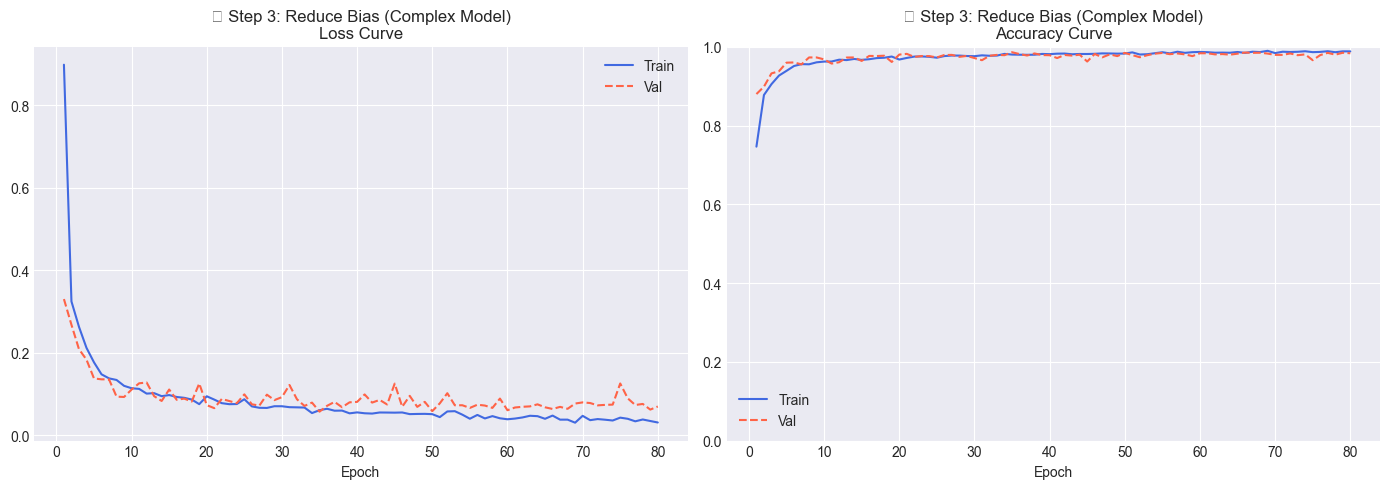

  Plot summary → Train acc: 0.988  |  Val acc: 0.984


In [23]:
# ============================================================
#  🔴 STEP 3 — REDUCE BIAS: Deep Complex Model
#  No new library imports — torch, nn, optim already loaded.
#  4 hidden layers + BatchNorm.  NO Dropout — we WANT overfit!
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

print('=' * 55)
print('  🔴 STEP 3: REDUCE BIAS — Deep Complex Model')
print('=' * 55)

class ComplexModel(nn.Module):
    """
    4 hidden layers with BatchNorm after each one.
    BatchNorm normalises each mini-batch → stable, faster training.
    NO Dropout — we want to overfit on purpose to prove capacity!
    """
    def __init__(self, in_f, n_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256),  nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64,  n_cls)
        )
    def forward(self, x): return self.net(x)

complex_model  = ComplexModel(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
complex_optim  = optim.Adam(complex_model.parameters(), lr=1e-3)
complex_params = sum(p.numel() for p in complex_model.parameters() if p.requires_grad)

# Print all setup values before training
print(f'  Architecture       : 4 hidden layers [256→256→128→64] + BatchNorm each')
print(f'  Trainable params   : {complex_params:,}')
print(f'  Capacity vs step 2 : {complex_params/baseline_params:.1f}x more parameters')
print(f'  Optimizer          : Adam   lr=1e-3')
print(f'  Dropout            : None  (intentional — want to overfit!)')
print(f'  BatchNorm          : Yes   (one after each hidden layer)')
print(f'  Epochs             : 80')
print(f'  Baseline to beat   : val_acc = {BASELINE_VAL_ACC:.3f}')
print()

complex_history = train_model(
    complex_model, train_loader, val_loader,
    complex_optim, criterion, epochs=80
)

cx_test_loss, cx_test_acc = evaluate(complex_model, test_loader, criterion)
cx_train_acc  = complex_history['train_acc'][-1]
cx_val_acc    = complex_history['val_acc'][-1]
overfit_gap   = cx_train_acc - cx_val_acc

print()
print('  📊 COMPLEX MODEL RESULTS')
print(f'  Train loss (final) : {complex_history["train_loss"][-1]:.4f}')
print(f'  Train acc  (final) : {cx_train_acc:.3f}')
print(f'  Val   loss (final) : {complex_history["val_loss"][-1]:.4f}')
print(f'  Val   acc  (final) : {cx_val_acc:.3f}')
print(f'  Test  loss         : {cx_test_loss:.4f}')
print(f'  Test  acc          : {cx_test_acc:.3f}  ({cx_test_acc*100:.1f}%)')
print(f'  Train/Val gap      : {overfit_gap:.3f}  ← the overfitting signal')
print(f'  Improved baseline? : {"✅ YES" if cx_val_acc > BASELINE_VAL_ACC else "❌ No"}')
if overfit_gap > 0.05:
    print(f'  Diagnosis          : ⚠️  OVERFITTING (gap > 5%) → go to Step 4')
elif cx_train_acc < 0.70:
    print(f'  Diagnosis          : ⚠️  Still UNDERFITTING → try bigger model')
else:
    print(f'  Diagnosis          : ✅ Good capacity → regularise to close the gap')
print('=' * 55)

plot_history(complex_history, title='🔴 Step 3: Reduce Bias (Complex Model)')

---
# 🥇 GOLDEN RULE — STEP 4: Reduce Variance (Fix Overfitting)
### Strategy: **Full data + Complex model + Regularisation = Gold Standard**

No new libraries here — all already imported.

**Toolkit applied:**
- **Dropout** — randomly kills 30% of neurons per forward pass
- **L2 Weight Decay** — penalises large weights in the optimiser
- **ReduceLROnPlateau** — halves LR when val loss stops improving
- **Early Stopping** — halts before overfitting takes over

> 🛡️ Regularisation = teaching discipline. Learn rules, not memorised examples.

  🥇 STEP 4: GOLD STANDARD — Regularised Model
  Architecture       : 4 hidden layers [256→256→128→64] + BatchNorm + Dropout
  Trainable params   : 125,906
  Dropout rate       : 0.3 on layers 1–3  /  0.15 on layer 4
  L2 weight decay    : 0.0001
  Optimizer          : Adam   lr=0.001
  LR scheduler       : ReduceLROnPlateau  factor=0.5  patience=10
  Max epochs         : 150
  Early stop patience: 20 epochs without val_loss improvement
  Baseline to beat   : val_acc = 0.970

  Epoch  10/150  |  Train loss=0.3451 acc=0.859  |  Val loss=0.2295 acc=0.901  |  LR=1.00e-03  |  No-improve=1/20
  Epoch  20/150  |  Train loss=0.2687 acc=0.900  |  Val loss=0.1702 acc=0.945  |  LR=1.00e-03  |  No-improve=0/20
  Epoch  30/150  |  Train loss=0.2026 acc=0.935  |  Val loss=0.1087 acc=0.970  |  LR=1.00e-03  |  No-improve=2/20
  Epoch  40/150  |  Train loss=0.1680 acc=0.949  |  Val loss=0.0867 acc=0.976  |  LR=1.00e-03  |  No-improve=4/20
  Epoch  50/150  |  Train loss=0.1567 acc=0.953  |  Val loss=0.0

C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\13832505.py:68: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


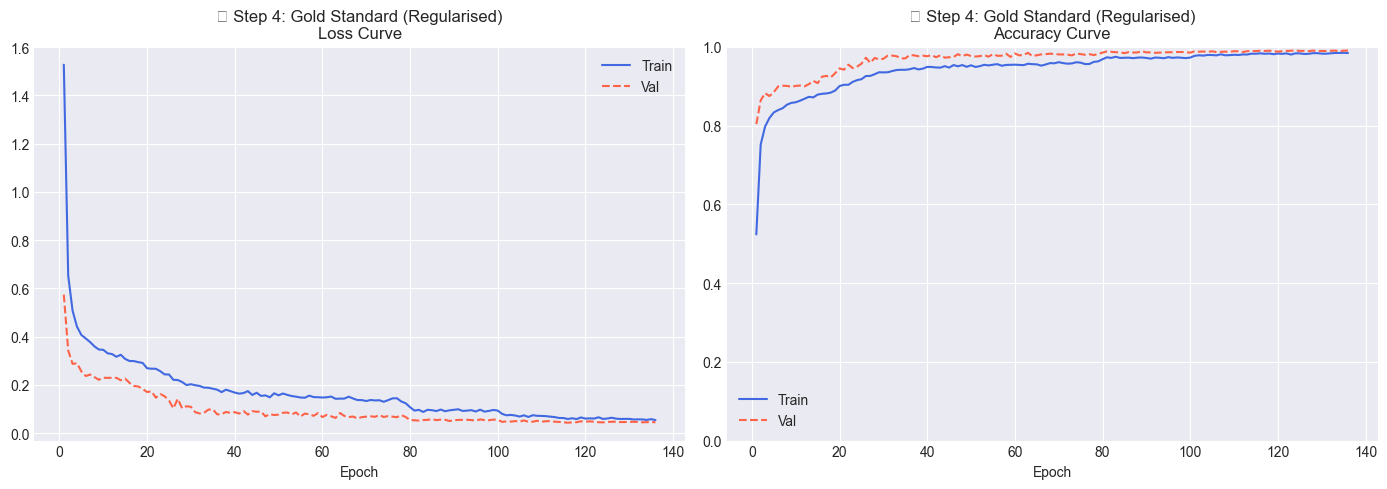

  Plot summary → Train acc: 0.984  |  Val acc: 0.991


In [24]:
# ============================================================
#  🥇 STEP 4 — GOLD STANDARD: Regularised Model
#  No new library imports — torch, nn, optim already loaded.
#  Same depth as Step 3 + Dropout + L2 decay + Early Stopping.
# ============================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

# All hyperparameters in one place — easy to tune later
DROPOUT_RATE = 0.3
WEIGHT_DECAY = 1e-4
LR_INIT      = 1e-3
LR_FACTOR    = 0.5
LR_PATIENCE  = 10
MAX_EPOCHS   = 150
ES_PATIENCE  = 20

print('=' * 55)
print('  🥇 STEP 4: GOLD STANDARD — Regularised Model')
print('=' * 55)

class RegularizedModel(nn.Module):
    """
    Same depth as ComplexModel + Dropout after each hidden layer:
      layers 1–3 → Dropout(0.30)  kills 30% of neurons randomly
      layer  4   → Dropout(0.15)  lighter near the output
    L2 penalty applied via optimizer weight_decay parameter.
    """
    def __init__(self, in_f, n_cls, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 256),  nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p / 2),
            nn.Linear(64,  n_cls)
        )
    def forward(self, x): return self.net(x)

reg_model  = RegularizedModel(NUM_FEATURES, NUM_CLASSES, p=DROPOUT_RATE).to(DEVICE)
reg_optim  = optim.Adam(reg_model.parameters(), lr=LR_INIT, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    reg_optim, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE
)
reg_params = sum(p.numel() for p in reg_model.parameters() if p.requires_grad)

# Print ALL hyperparameters before training
print(f'  Architecture       : 4 hidden layers [256→256→128→64] + BatchNorm + Dropout')
print(f'  Trainable params   : {reg_params:,}')
print(f'  Dropout rate       : {DROPOUT_RATE} on layers 1–3  /  {DROPOUT_RATE/2} on layer 4')
print(f'  L2 weight decay    : {WEIGHT_DECAY}')
print(f'  Optimizer          : Adam   lr={LR_INIT}')
print(f'  LR scheduler       : ReduceLROnPlateau  factor={LR_FACTOR}  patience={LR_PATIENCE}')
print(f'  Max epochs         : {MAX_EPOCHS}')
print(f'  Early stop patience: {ES_PATIENCE} epochs without val_loss improvement')
print(f'  Baseline to beat   : val_acc = {BASELINE_VAL_ACC:.3f}')
print()

# ── Training loop with Early Stopping ────────────────────────
best_val_loss = float('inf')
best_state    = None
no_improve    = 0
stopped_epoch = MAX_EPOCHS
reg_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, MAX_EPOCHS + 1):
    tl, ta = train_one_epoch(reg_model, train_loader, reg_optim, criterion)
    vl, va = evaluate(reg_model, val_loader, criterion)
    reg_history['train_loss'].append(tl)
    reg_history['val_loss'].append(vl)
    reg_history['train_acc'].append(ta)
    reg_history['val_acc'].append(va)

    scheduler.step(vl)    # reduce LR if val_loss plateaus

    # Save best weights checkpoint
    if vl < best_val_loss:
        best_val_loss = vl
        best_state    = {k: v.cpu().clone() for k, v in reg_model.state_dict().items()}
        no_improve    = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        current_lr = reg_optim.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{MAX_EPOCHS}'
              f'  |  Train loss={tl:.4f} acc={ta:.3f}'
              f'  |  Val loss={vl:.4f} acc={va:.3f}'
              f'  |  LR={current_lr:.2e}'
              f'  |  No-improve={no_improve}/{ES_PATIENCE}')

    if no_improve >= ES_PATIENCE:
        stopped_epoch = epoch
        print(f'\n  🛑 Early Stopping triggered at epoch {epoch}')
        break

# Restore best saved weights
reg_model.load_state_dict(best_state)
print(f'  🔄 Best weights restored  (best val_loss = {best_val_loss:.4f})')

rg_test_loss, rg_test_acc = evaluate(reg_model, test_loader, criterion)
rg_train_acc  = reg_history['train_acc'][-1]
rg_val_acc    = reg_history['val_acc'][-1]
rg_gap        = rg_train_acc - rg_val_acc

print()
print('  📊 GOLD STANDARD RESULTS')
print(f'  Epochs trained     : {stopped_epoch}  (max was {MAX_EPOCHS})')
print(f'  Best val loss      : {best_val_loss:.4f}')
print(f'  Train loss (final) : {reg_history["train_loss"][-1]:.4f}')
print(f'  Train acc  (final) : {rg_train_acc:.3f}')
print(f'  Val   loss (final) : {reg_history["val_loss"][-1]:.4f}')
print(f'  Val   acc  (final) : {rg_val_acc:.3f}')
print(f'  Test  loss         : {rg_test_loss:.4f}')
print(f'  Test  acc          : {rg_test_acc:.3f}  ({rg_test_acc*100:.1f}%)')
print(f'  Train/Val gap      : {rg_gap:.3f}'
      f'  (Step 3 was {overfit_gap:.3f} — reduced? {"✅" if rg_gap < overfit_gap else "❌"})')
print(f'  Beat baseline?     : {"✅ YES" if rg_val_acc > BASELINE_VAL_ACC else "❌ No"}')
print('=' * 55)

plot_history(reg_history, title='🥇 Step 4: Gold Standard (Regularised)')

---
## 📊 Section 5 — Final Evaluation: Confusion Matrix & Classification Report

Libraries used here: **Scikit-learn** (`confusion_matrix`, `classification_report`) — already imported in Section 2.
**Seaborn** for the heatmap — already imported in Section 1b.

One accuracy number hides a lot. The confusion matrix tells the full story! 🔍

  📦 LIBRARIES USED IN THIS CELL (already imported)
  Scikit-learn : 1.8.0  → confusion_matrix, classification_report
  Seaborn      : 0.13.2  → heatmap
  PyTorch      : 2.10.0+cpu  → model inference

  Total test samples  : 3852
  Correct predictions : 3807
  Wrong  predictions  : 45
  Overall accuracy    : 0.988



C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\4028915409.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


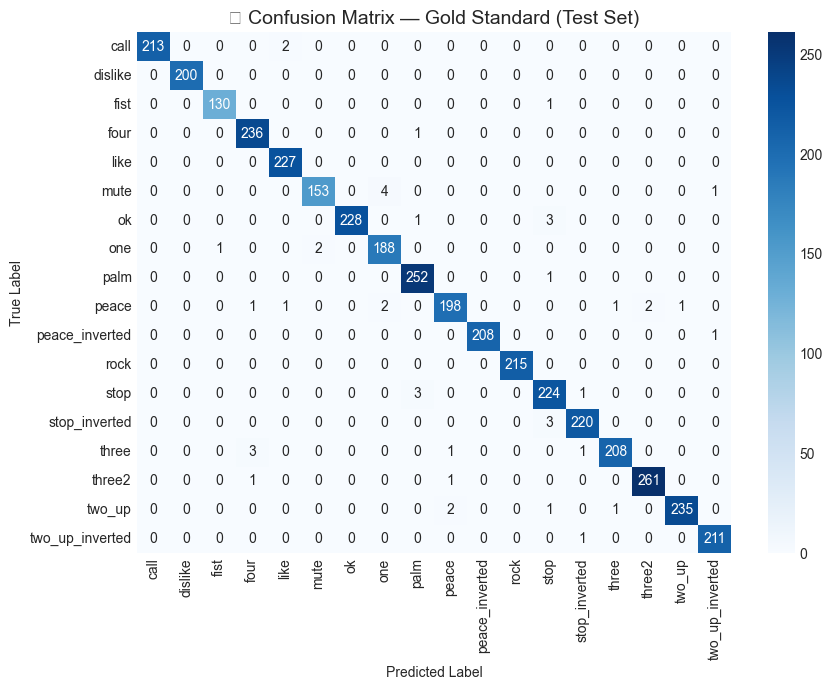

  📋 CLASSIFICATION REPORT — Gold Standard on Test Set
                 precision    recall  f1-score   support

           call       1.00      0.99      1.00       215
        dislike       1.00      1.00      1.00       200
           fist       0.99      0.99      0.99       131
           four       0.98      1.00      0.99       237
           like       0.99      1.00      0.99       227
           mute       0.99      0.97      0.98       158
             ok       1.00      0.98      0.99       232
            one       0.97      0.98      0.98       191
           palm       0.98      1.00      0.99       253
          peace       0.98      0.96      0.97       206
 peace_inverted       1.00      1.00      1.00       209
           rock       1.00      1.00      1.00       215
           stop       0.96      0.98      0.97       228
  stop_inverted       0.99      0.99      0.99       223
          three       0.99      0.98      0.98       213
         three2       0.99      0

In [27]:
# ============================================================
#  SECTION 5 — DETAILED EVALUATION
#  No new library imports — sklearn, seaborn, torch already loaded.
#  confusion_matrix & classification_report from sklearn.
#  sns.heatmap from seaborn.
# ============================================================

# Remind reader which libraries power this cell
from sklearn.metrics import confusion_matrix, classification_report
print('  📦 LIBRARIES USED IN THIS CELL (already imported)')
print(f'  Scikit-learn : {sklearn.__version__}  → confusion_matrix, classification_report')
print(f'  Seaborn      : {sns.__version__}  → heatmap')
print(f'  PyTorch      : {torch.__version__}  → model inference')
print()

@torch.no_grad()
def collect_preds(model, loader):
    """Run entire loader and collect all predictions + true labels."""
    model.eval()
    preds, labels = [], []
    for X_b, y_b in loader:
        out = model(X_b.to(DEVICE))
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y_b.numpy())
    return np.array(preds), np.array(labels)

y_pred, y_true = collect_preds(reg_model, test_loader)

# ── Print prediction stats ────────────────────────────────────
print(f'  Total test samples  : {len(y_true)}')
print(f'  Correct predictions : {(y_pred == y_true).sum()}')
print(f'  Wrong  predictions  : {(y_pred != y_true).sum()}')
print(f'  Overall accuracy    : {(y_pred == y_true).mean():.3f}')
print()

# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('🔍 Confusion Matrix — Gold Standard (Test Set)', fontsize=14)
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout(); plt.show()

# ── Classification report ─────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
print('  📋 CLASSIFICATION REPORT — Gold Standard on Test Set')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── Print key numbers in a clean table ───────────────────────
print(f'  {"Class":<15} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('  ' + '-' * 55)
for cls in CLASS_NAMES:
    r = report[cls]
    print(f'  {cls:<15} {r["precision"]:>10.3f} {r["recall"]:>10.3f}'
          f' {r["f1-score"]:>10.3f} {int(r["support"]):>10}')
print('  ' + '-' * 55)
print(f'  {"Accuracy":<15} {"-":>10} {"-":>10} {report["accuracy"]:>10.3f}')
print(f'  {"Macro avg":<15} {report["macro avg"]["precision"]:>10.3f}'
      f' {report["macro avg"]["recall"]:>10.3f} {report["macro avg"]["f1-score"]:>10.3f}')
print(f'  {"Weighted avg":<15} {report["weighted avg"]["precision"]:>10.3f}'
      f' {report["weighted avg"]["recall"]:>10.3f} {report["weighted avg"]["f1-score"]:>10.3f}')
print()
print('  💡 precision = of all predicted-as-X, how many were truly X')
print('     recall    = of all actual X,       how many did we catch')
print('     f1        = harmonic mean of precision and recall')

---
## 🏁 Section 6 — Full Journey Comparison

No new libraries — Matplotlib already imported in Section 1b.

All 4 steps side by side — see the progression clearly! 🗺️

  📦 LIBRARIES USED IN THIS CELL (already imported)
  Matplotlib : 3.10.8  → comparison plots
  PyTorch    : 2.10.0+cpu  → final model evaluation



C:\Users\Atif\AppData\Local\Temp\ipykernel_21372\3392308884.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\Atif\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


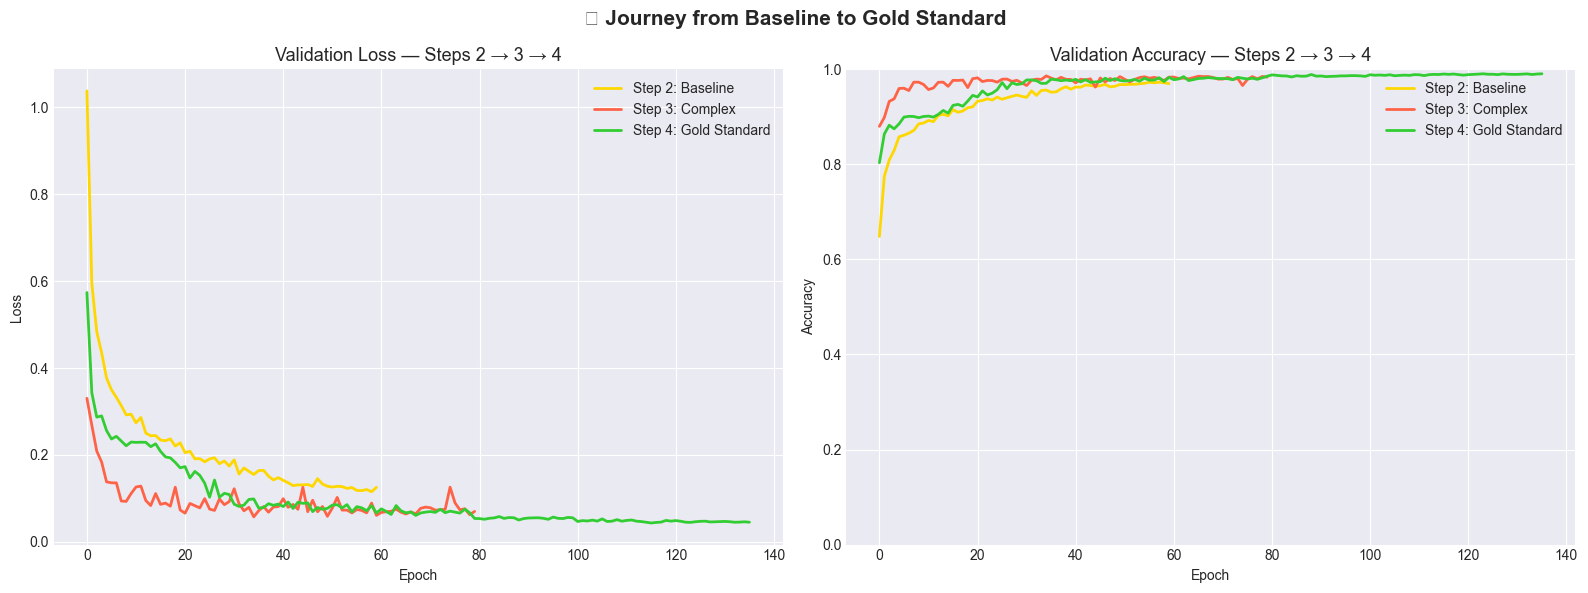

  🏁 FINAL SUMMARY — The 4 Golden Rules Journey
  Step     Description                    Val Acc  Test Acc      Gap
  --------------------------------------------------------------------
  Step 1   Sanity Check (1 sample)          1.000       N/A      N/A
  Step 2   Baseline (simple)                0.970     0.972    0.011
  Step 3   Reduce Bias (complex)            0.984     0.983    0.005
  Step 4   Gold Standard (regularised)      0.991     0.988   -0.006

  🥇 WHAT WE LEARNED AT EACH STEP:
  Step 1 → confirmed the code pipeline works (1-sample overfit)
  Step 2 → set a measurable reference score (simple model)
  Step 3 → added capacity, reduced bias (but increased variance)
  Step 4 → regularised, reduced variance → Gold Standard! 🎉

  💡 Methodical, measurable improvement every step.
     This is the professional way to train Neural Networks! 🚀


In [28]:
# ============================================================
#  SECTION 6 — FULL JOURNEY COMPARISON
#  No new library imports — matplotlib already loaded in Section 1b.
#  Overlay val curves of Steps 2, 3, 4 to visualise improvement.
# ============================================================

print('  📦 LIBRARIES USED IN THIS CELL (already imported)')
print(f'  Matplotlib : {matplotlib.__version__}  → comparison plots')
print(f'  PyTorch    : {torch.__version__}  → final model evaluation')
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(baseline_history['val_loss'], label='Step 2: Baseline',     color='gold',      lw=2)
axes[0].plot(complex_history['val_loss'],  label='Step 3: Complex',       color='tomato',    lw=2)
axes[0].plot(reg_history['val_loss'],      label='Step 4: Gold Standard', color='limegreen', lw=2)
axes[0].set_title('Validation Loss — Steps 2 → 3 → 4', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(baseline_history['val_acc'], label='Step 2: Baseline',     color='gold',      lw=2)
axes[1].plot(complex_history['val_acc'],  label='Step 3: Complex',       color='tomato',    lw=2)
axes[1].plot(reg_history['val_acc'],      label='Step 4: Gold Standard', color='limegreen', lw=2)
axes[1].set_title('Validation Accuracy — Steps 2 → 3 → 4', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend()

plt.suptitle('📈 Journey from Baseline to Gold Standard', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Final summary table ───────────────────────────────────────
print('=' * 70)
print('  🏁 FINAL SUMMARY — The 4 Golden Rules Journey')
print('=' * 70)
print(f'  {"Step":<8} {"Description":<28} {"Val Acc":>9} {"Test Acc":>9} {"Gap":>8}')
print('  ' + '-' * 68)

bl_gap = baseline_history['train_acc'][-1] - baseline_history['val_acc'][-1]

print(f'  {"Step 1":<8} {"Sanity Check (1 sample)":<28}'
      f' {sanity_history["val_acc"][-1]:>9.3f} {"N/A":>9} {"N/A":>8}')
print(f'  {"Step 2":<8} {"Baseline (simple)":<28}'
      f' {baseline_history["val_acc"][-1]:>9.3f} {bl_test_acc:>9.3f} {bl_gap:>8.3f}')
print(f'  {"Step 3":<8} {"Reduce Bias (complex)":<28}'
      f' {cx_val_acc:>9.3f} {cx_test_acc:>9.3f} {overfit_gap:>8.3f}')
print(f'  {"Step 4":<8} {"Gold Standard (regularised)":<28}'
      f' {rg_val_acc:>9.3f} {rg_test_acc:>9.3f} {rg_gap:>8.3f}')

print('=' * 70)
print()
print('  🥇 WHAT WE LEARNED AT EACH STEP:')
print('  Step 1 → confirmed the code pipeline works (1-sample overfit)')
print('  Step 2 → set a measurable reference score (simple model)')
print('  Step 3 → added capacity, reduced bias (but increased variance)')
print('  Step 4 → regularised, reduced variance → Gold Standard! 🎉')
print()
print('  💡 Methodical, measurable improvement every step.')
print('     This is the professional way to train Neural Networks! 🚀')